# 🧩 01-数据结构与算法 · 主题 8：动态规划（重头戏）

> DP 是秋招算法**第一重点**：考察「把大问题分解为重叠子问题 + 最优子结构」的建模能力。
> 本 notebook 目标：**吃透四步法 → 掌握背包/LIS/LCS/编辑距离/区间/股票六大模板 → 通过 25 道自测**。

**前置**：主题 7（递归）。**运行环境**：Python 3.8+，无第三方依赖。

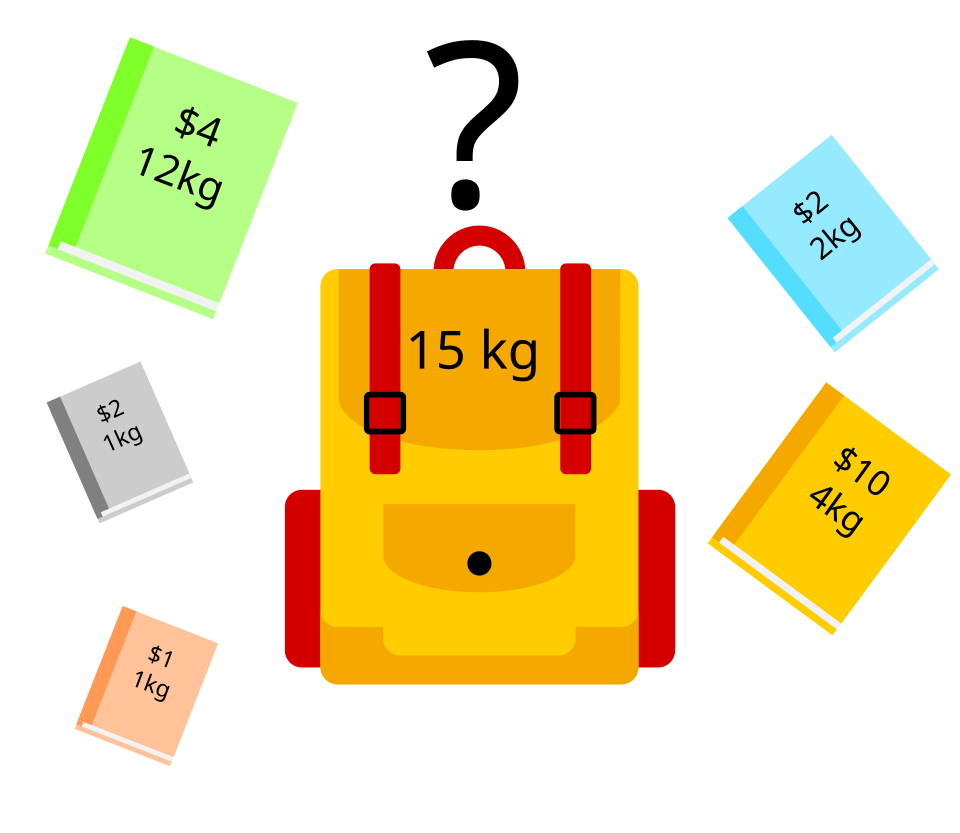

> 📷 0-1 背包：在容量约束下选物品使价值最大（DP 二维→一维滚动）
> *图源：Wikimedia Commons（开放授权）*


## §1 四步法（写任何 DP 前先默写）

### 判断 DP 的两把尺子

- **最优子结构**：全局最优可由子问题最优组合而成（贪心不满足时才想到 DP）
- **重叠子问题**：不同路径会反复计算同一个子问题（递归爆搜会重复）

**反例**：最长简单路径无最优子结构（不可分）；贪心可解的题强用 DP 是杀鸡用牛刀。

### 四步法

1. **定义状态** $dp[i]$：$i$ 的含义（下标/容量/长度）+ $dp[i]$ 存什么（最大值/方案数/布尔）
2. **转移方程**：$dp[i]$ 从哪些更小的状态推来
3. **初始化**：边界（$dp[0]$、$dp[1]$、空串/空背包）
4. **遍历顺序**：一维从前往后 / 从后往前（背包逆序）；二维行主序 / 按区间长度

### 两类实现

- **自底向上（递推）**：for 循环填表，面试默认写法，省递归栈
- **自顶向下（记忆化搜索）**：递归 + memo 字典/数组，思路直白、无需考虑遍历顺序

$$\text{记忆化} \iff \text{递推} \quad (\text{时间复杂度相同，空间记忆化多递归栈})$$

## §2 一维 DP：爬楼梯 / 打家劫舍 / 最大子数组和

### 70 爬楼梯

一次爬 1 或 2 阶：

$$dp[i] = dp[i-1] + dp[i-2], \quad dp[1]=1,\ dp[2]=2$$

滚动变量优化空间 $O(1)$（只保留前两个）。

### 198 打家劫舍（不可取相邻）

$$dp[i] = \max(dp[i-1],\ dp[i-2] + nums[i])$$

- 不偷 $i$：继承 $dp[i-1]$；偷 $i$：$dp[i-2] + nums[i]$

### 53 最大子数组和（Kadane）

$$dp[i] = \max(nums[i],\ dp[i-1] + nums[i])$$

要么新开一段（`nums[i]`），要么接续前一段。

### 121 买卖股票的最佳时机（只能买卖一次）

$$dp[i] = \max(dp[i-1],\ nums[i] - \min_{j<i} nums[j])$$

等价于维护**历史最低价**，一趟遍历。

In [ ]:
def climb_stairs(n):
    a, b = 1, 2                    # dp[1], dp[2]
    for _ in range(3, n + 1):
        a, b = b, a + b
    return b if n >= 2 else a

def rob(nums):
    prev2, prev1 = 0, 0
    for x in nums:
        cur = max(prev1, prev2 + x)   # 不偷 vs 偷当前
        prev2, prev1 = prev1, cur
    return prev1

def max_sub_array(nums):
    best = cur = nums[0]
    for x in nums[1:]:
        cur = max(x, cur + x)        # 新开一段 vs 接续
        best = max(best, cur)
    return best

def max_profit(prices):
    min_price = float('inf')
    best = 0
    for p in prices:
        min_price = min(min_price, p)
        best = max(best, p - min_price)
    return best

print('climb(5) =', climb_stairs(5))            # 期望 8
print('rob([2,7,9,3,1]) =', rob([2, 7, 9, 3, 1]))  # 期望 12（2+9+1）
print('rob([2,1,1,2]) =', rob([2, 1, 1, 2]))    # 期望 4（2+2）
print('max_sub_array([-2,1,-3,4,-1,2,1,-5,4]) =', max_sub_array([-2, 1, -3, 4, -1, 2, 1, -5, 4]))  # 6
print('max_profit([7,1,5,3,6,4]) =', max_profit([7, 1, 5, 3, 6, 4]))  # 期望 5

## §3 背包问题（面试手撕重灾区）

### 01 背包（每件只取一次）

容量 $W$、物品 $i$ 重 $w_i$ 值 $v_i$：

$$dp[j] = \max(dp[j],\ dp[j - w_i] + v_i), \quad j \text{ 从大到小遍历}$$

**为什么容量逆序遍历**：正序会让同一物品被重复取（dp[j-w] 已经是更新后的值）。

**滚动数组降维**：二维 $dp[i][j] \to$ 一维 $dp[j]$，省一维空间。

### 完全背包（每件无限取）

$$dp[j] = \max(dp[j],\ dp[j - w_i] + v_i), \quad j \text{ 从小到大遍历}$$

**区别只有遍历方向**——面试必问：01 逆序防重复，完全正序允许重复。

### 416 分割等和子集（01 背包变形）

**能分成两个和相等的子集** $\iff$ 存在子集和为 $sum/2$（$sum$ 必须为偶数）：

$$dp[j] = dp[j] \lor dp[j - nums[i]]$$

### 518 零钱兑换 II（完全背包求方案数）

$$dp[j] = dp[j] + dp[j - coin] \quad (\text{先遍历硬币，防顺序不同的重复})$$

In [ ]:
def knapsack_01(weights, values, W):
    # 标准 01 背包模板：返回最大价值
    dp = [0] * (W + 1)
    for w, v in zip(weights, values):
        for j in range(W, w - 1, -1):    # 逆序：防止同一物品重复取
            dp[j] = max(dp[j], dp[j - w] + v)
    return dp[W]

def can_partition(nums):
    total = sum(nums)
    if total % 2:
        return False
    target = total // 2
    dp = [False] * (target + 1)
    dp[0] = True
    for x in nums:
        for j in range(target, x - 1, -1):
            dp[j] = dp[j] or dp[j - x]
    return dp[target]

def change(amount, coins):
    # 完全背包：组合数（先硬币后金额）
    dp = [0] * (amount + 1)
    dp[0] = 1
    for c in coins:
        for j in range(c, amount + 1):   # 正序：允许重复使用
            dp[j] += dp[j - c]
    return dp[amount]

print('01背包(最大价值):', knapsack_01([1, 3, 4], [15, 20, 30], 4))   # 期望 35（1+3）
print('can_partition([1,5,11,5]) =', can_partition([1, 5, 11, 5]))    # 期望 True
print('can_partition([1,2,5]) =', can_partition([1, 2, 5]))           # 期望 False
print('change(5,[1,2,5]) =', change(5, [1, 2, 5]))                    # 期望 4
print('change(3,[2]) =', change(3, [2]))                              # 期望 0

## §3.1 01 背包滚动数组：为什么容量必须逆序（白板演算）

具体例子：`weights=[1,3,4]`, `values=[15,20,30]`, 容量 `W=4`，期望最优 = **35**（取物品 1 + 3：15+20）。

**二维写法** `dp[i][j]`（i 件物品、容量 j）：

| i\j | 0 | 1 | 2 | 3 | 4 |
|-----|---|---|---|---|---|
| 0 | 0 | 0 | 0 | 0 | 0 |
| 1(w1,v1) | 0 | 15 | 15 | 15 | 15 |
| 2(w3,v3) | 0 | 15 | 15 | 20 | 35 |
| 3(w4,v4) | 0 | 15 | 15 | 20 | 35 |

**一维滚动** `dp[j]`：第 i 行只依赖第 i-1 行旧值，所以原地更新时必须保证读到的还是**旧值**。

**为什么逆序**：内层 `for j in range(W, w-1, -1)`，`dp[j] = max(dp[j], dp[j-w]+v)`。逆序时 `dp[j-w]` 是**本轮尚未更新的旧值**（第 i-1 行的结果）；若正序，`dp[j-w]` 可能已被本行新值覆盖 → 同一件物品被取多次（退化成分数/完全背包）。

```
正序（错误）: j=1 更新 dp[1]=15 → j=2 读 dp[1]=15（已被污染）→ dp[2]=30 ✗ 物品取了两次
逆序（正确）: j=4 读 dp[3]（旧值 0）→ ... → j=2 读 dp[1]（本轮还没碰，旧值 0）→ dp[2]=15 ✓
```

> 💡 **一句话记忆**：逆序 = 保证每个容量只被"上一轮的结果"更新一次 → 每件物品最多取一次。

## §4 最长类：LIS / LCS / 最长回文子串

### 300 最长递增子序列（LIS）

$$dp[i] = 1 + \max_{j < i,\ nums[j] < nums[i]} dp[j] \quad \Rightarrow \quad O(n^2)$$

**贪心 + 二分优化 $O(n \log n)$**：维护 `tails[k]` = 长度为 $k+1$ 的递增子序列的最小结尾；`bisect_left` 定位替换点——**只更新最小结尾，不丢失更小值**。

### 1143 最长公共子序列（LCS）

$$dp[i][j] = \begin{cases} dp[i-1][j-1] + 1 & a_i = b_j \\ \max(dp[i-1][j],\ dp[i][j-1]) & a_i \ne b_j \end{cases}$$

### 5 最长回文子串（区间 DP / 中心扩展）

区间 DP 判回文：

$$dp[i][j] = (s_i = s_j) \land dp[i+1][j-1]$$

**复杂度**：$O(n^2)$（中心扩展 $O(n^2)$ 但常数小，常被面试要求）

In [ ]:
from bisect import bisect_left

def length_of_lis(nums):
    tails = []
    for x in nums:
        i = bisect_left(tails, x)     # 第一个 >= x 的位置
        if i == len(tails):
            tails.append(x)
        else:
            tails[i] = x              # 更新最小结尾
    return len(tails)

def longest_common_subsequence(a, b):
    m, n = len(a), len(b)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if a[i - 1] == b[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
    return dp[m][n]

def longest_palindrome(s):
    n = len(s)
    if n < 2:
        return s
    start, max_len = 0, 1
    dp = [[False] * n for _ in range(n)]
    for i in range(n):
        dp[i][i] = True
    # 按长度从小到大填表（区间 DP 遍历顺序）
    for L in range(2, n + 1):
        for i in range(n - L + 1):
            j = i + L - 1
            if s[i] == s[j] and (L == 2 or dp[i + 1][j - 1]):
                dp[i][j] = True
                if L > max_len:
                    start, max_len = i, L
    return s[start:start + max_len]

print('LIS([10,9,2,5,3,7,101,18]) =', length_of_lis([10, 9, 2, 5, 3, 7, 101, 18]))  # 4
print('LIS([0,1,0,3,2,3]) =', length_of_lis([0, 1, 0, 3, 2, 3]))                     # 4
print('LCS(abcde,ace) =', longest_common_subsequence('abcde', 'ace'))               # 3
print('LCS(abc,def) =', longest_common_subsequence('abc', 'def'))                   # 0
print('longest_palindrome(babad) =', longest_palindrome('babad'))                   # bab/aba
print('longest_palindrome(cbbd) =', longest_palindrome('cbbd'))                     # bb

## §4.1 为什么 LIS 的 O(n log n)（tails 二分）正确（证明）

**定义**：`tails[k]` = 长度为 `k+1` 的递增子序列的**最小结尾值**。

**性质 1（单调递增）**：`tails` 严格递增。反证：若 `tails[i] >= tails[j] (i<j)`，则长度为 j 的子序列的结尾 ≥ 长度为 i 的结尾，但长度为 j 的子序列**去掉末尾**就是一个长度为 i 的更优候选，矛盾。

**性质 2（二分替换不丢最优解）**：对每个新数 `x`，找 `pos = bisect_left(tails, x)`（第一个 ≥ x 的位置）并替换。替换后：
- 以 `tails[pos] = x` 结尾的长度 pos+1 子序列**仍合法**（前 pos 个元素都 < x，因为 tails 严格递增）；
- `tails[pos]` 变小只会让后续数更容易接上 → 不劣化任何已有分组。

**结论**：遍历一遍，每次 O(log n) 替换，总复杂度 **O(n log n)**；最终答案 = len(tails)。

## §5 编辑距离（LeetCode 72，必背推导）

**题目**：把 $A$ 变成 $B$ 的最少操作数（插入/删除/替换）。

**状态**：$dp[i][j]$ = $A$ 前 $i$ 个字符 → $B$ 前 $j$ 个字符的最小编辑距离。

**转移方程**（三种操作对应三项）：

$$dp[i][j] = \begin{cases} dp[i-1][j-1] & a_i = b_j \\ 1 + \min\big(\underbrace{dp[i-1][j]}_{\text{删除} a_i},\ \underbrace{dp[i][j-1]}_{\text{插入} b_j},\ \underbrace{dp[i-1][j-1]}_{\text{替换}}\big) & a_i \ne b_j \end{cases}$$

**初始化**：$dp[i][0] = i$（全删），$dp[0][j] = j$（全插）。

**复杂度**：$O(mn)$ 时间，$O(mn)$ 空间（可滚动到 $O(m)$）。

## §5.1 编辑距离 horse → ros 填表演算（白板标准演示）

`dp[i][j]` = `word1[:i]` → `word2[:j]` 最少操作数；`dp[0][j]=j`（插入 j 次）、`dp[i][0]=i`（删除 i 次）。

| dp | '' | r | o | s |
|----|----|----|----|----|
| '' | 0 | 1 | 2 | 3 |
| h | 1 | 1 | 2 | 3 |
| o | 2 | 2 | 1 | 2 |
| r | 3 | 2 | 2 | 2 |
| s | 4 | 3 | 3 | 2 |
| e | 5 | 4 | 4 | 3 |

**递推来源**（取三方向最小值 + 替换代价）：

$$dp[i][j] = \min\big(dp[i-1][j]+1 \ (删),\ dp[i][j-1]+1 \ (插),\ dp[i-1][j-1]+\mathbb{1}[word1_i \neq word2_j] \ (替/留)\big)$$

逐格来源示例：`dp[2][2]`（"ho"→"ro"）= min(`dp[1][2]+1`=3, `dp[2][1]+1`=3, `dp[1][1]+0`=1) = **1**（o 与 o 相等保留）。答案 `dp[5][3]=3`（horse→ros 需 3 次：h→r、删 e、删 s 或等价操作）。

> 💡 **填表顺序**：行从左到右、列从上到下即可——因为每个格子只依赖上/左/左上，已在前面算好。

In [ ]:
def min_distance(word1, word2):
    m, n = len(word1), len(word2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i                    # 删除 i 次
    for j in range(n + 1):
        dp[0][j] = j                    # 插入 j 次
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if word1[i - 1] == word2[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]
            else:
                dp[i][j] = 1 + min(dp[i - 1][j],      # 删除
                                   dp[i][j - 1],      # 插入
                                   dp[i - 1][j - 1])  # 替换
    return dp[m][n]

print('horse->ros =', min_distance('horse', 'ros'))     # 期望 3
print('intention->execution =', min_distance('intention', 'execution'))  # 期望 5
print('空串->abc =', min_distance('', 'abc'))            # 期望 3
print('a->a =', min_distance('a', 'a'))                  # 期望 0

## §6 区间 DP：最长回文子序列（516）

**状态**：$dp[i][j]$ = 子串 $s[i..j]$ 的最长回文子序列长度。

**转移**（按区间长度从短到长）：

$$dp[i][j] = \begin{cases} dp[i+1][j-1] + 2 & s_i = s_j \\ \max(dp[i+1][j],\ dp[i][j-1]) & s_i \ne s_j \end{cases}$$

**遍历顺序**：外层枚举**区间长度**、内层枚举**起点**——保证 dp[i+1][j-1] 已先被算到（这是区间 DP 与普通二维 DP 最大的区别）。

**复杂度**：$O(n^2)$ 时间、$O(n^2)$ 空间（可滚动 $O(n)$）。

> 💡 类似题：戳气球 312、合并石头的最低成本 1000——先想「最后一步合并/分割」确定区间转移。

In [ ]:
def longest_palindrome_subseq(s):
    if not s:  # 空串直接返回 0（避免 dp[0][-1] 越界）
        return 0
    n = len(s)
    dp = [[0] * n for _ in range(n)]
    for i in range(n):
        dp[i][i] = 1
    for L in range(2, n + 1):              # 区间长度
        for i in range(0, n - L + 1):      # 起点
            j = i + L - 1
            if s[i] == s[j]:
                dp[i][j] = dp[i + 1][j - 1] + 2
            else:
                dp[i][j] = max(dp[i + 1][j], dp[i][j - 1])
    return dp[0][n - 1]

print('bbbab =', longest_palindrome_subseq('bbbab'))   # 期望 4（bbbb）
print('cbbd =', longest_palindrome_subseq('cbbd'))     # 期望 2（bb）
print('a =', longest_palindrome_subseq('a'))           # 期望 1
print('空 =', longest_palindrome_subseq(''))           # 期望 0

## §7 股票系列（状态机套路，一类题全通）

**通用状态机**：每天两种状态——持有（hold）或空仓（empty）：

- $hold[i]$：第 $i$ 天结束后**持有**股票的最大利润
- $empty[i]$：第 $i$ 天结束后**空仓**的最大利润

$$hold[i] = \max(hold[i-1],\ empty[i-1] - prices[i]) \quad (\text{买入})$$

$$empty[i] = \max(empty[i-1],\ hold[i-1] + prices[i]) \quad (\text{卖出})$$

**各题目差异**：

| 题 | 限制 | 改动 |
|----|------|------|
| 121 | 一次 | 记录一次到手利润 |
| 122 | 无限次 | 上述两式（可当日先卖后买） |
| 309 | 含冷冻期 | 空仓状态拆成「今天卖出 / 冷冻中」 |
| 714 | 含手续费 | 卖出时减去 $fee$ |
| 123/188 | 至多 k 次 | 状态加维度 $[k]$（第几次交易） |

In [ ]:
def max_profit_any(prices, fee=0):
    # 122/714：无限次交易，可选手续费
    hold = float('-inf')       # 持有股票
    empty = 0                  # 空仓
    for p in prices:
        new_hold = max(hold, empty - p)
        new_empty = max(empty, hold + p - fee)
        hold, empty = new_hold, new_empty
    return empty

def max_profit_k(prices, k):
    # 188：至多 k 次交易（经典状态机三维可滚动）
    if k == 0 or not prices:
        return 0
    # dp[j][0]=第j次交易后持仓, dp[j][1]=完成第j次交易
    hold = [float('-inf')] * (k + 1)
    sold = [0] * (k + 1)
    for p in prices:
        for j in range(1, k + 1):
            hold[j] = max(hold[j], sold[j - 1] - p)
            sold[j] = max(sold[j], hold[j] + p)
    return sold[k]

print('122 无限次 [7,1,5,3,6,4] =', max_profit_any([7, 1, 5, 3, 6, 4]))          # 7
print('714 含手续费 [1,3,2,8,4,9], fee=2 =', max_profit_any([1, 3, 2, 8, 4, 9], 2))  # 8
print('188 至多2次 [3,3,5,0,0,3,1,4] =', max_profit_k([3, 3, 5, 0, 0, 3, 1, 4], 2))  # 6
print('188 至多2次 [1,2,3,4,5] =', max_profit_k([1, 2, 3, 4, 5], 2))                  # 4

## §8 路径类：不同路径 / 最小路径和

### 62 不同路径（网格左上 → 右下）

$$dp[i][j] = dp[i-1][j] + dp[i][j-1], \quad dp[0][*] = dp[*][0] = 1$$

**组合数解法**：总共走 $m+n-2$ 步，选 $m-1$ 步向下：

$$\binom{m+n-2}{m-1}$$

### 64 最小路径和

$$dp[i][j] = grid[i][j] + \min(dp[i-1][j],\ dp[i][j-1])$$

**复杂度**：$O(mn)$ 时间，可滚动 $O(n)$ 空间。

In [ ]:
import math

def unique_paths(m, n):
    # 组合数解：C(m+n-2, m-1)，空间 O(1)
    return math.comb(m + n - 2, m - 1)

def unique_paths_dp(m, n):
    dp = [1] * n                    # 滚动数组：第一行全 1
    for _ in range(1, m):
        for j in range(1, n):
            dp[j] += dp[j - 1]
    return dp[n - 1]

def min_path_sum(grid):
    m, n = len(grid), len(grid[0])
    for i in range(m):
        for j in range(n):
            if i == 0 and j == 0:
                continue
            up = grid[i - 1][j] if i > 0 else float('inf')
            left = grid[i][j - 1] if j > 0 else float('inf')
            grid[i][j] += min(up, left)   # 原地更新
    return grid[m - 1][n - 1]

print('unique_paths(3,7) =', unique_paths(3, 7), '==', unique_paths_dp(3, 7))  # 28
print('unique_paths(3,2) =', unique_paths(3, 2))                               # 3
print('min_path_sum([[1,3,1],[1,5,1],[4,2,1]]) =',
      min_path_sum([[1, 3, 1], [1, 5, 1], [4, 2, 1]]))  # 期望 7
print('min_path_sum([[1]]) =', min_path_sum([[1]]))     # 期望 1

## §9 记忆化搜索示例（自顶向下）

以爬楼梯为例对比两种写法；记忆化 = 递归 + 缓存，**不用想遍历顺序**，适合区间 DP 等难推顺序的题：

```python
from functools import lru_cache

@lru_cache(None)
def climb(n):
    if n <= 2:
        return n
    return climb(n - 1) + climb(n - 2)
```

**何时选记忆化**：状态空间复杂、遍历顺序难确定（区间/树形 DP）；**何时选递推**：需要空间优化（滚动数组）或面试官要求 $O(1)$ 空间。

In [ ]:
from functools import lru_cache

@lru_cache(None)
def climb_memo(n):
    if n <= 2:
        return n
    return climb_memo(n - 1) + climb_memo(n - 2)

print('记忆化 climb(10) =', climb_memo(10), '（递推版 =', climb_stairs(10), '）')  # 89

# 记忆化的经典场景：单词拆分 139
def word_break(s, word_dict):
    wd = set(word_dict)
    @lru_cache(None)
    def dfs(i):
        if i == len(s):
            return True
        for j in range(i + 1, len(s) + 1):
            if s[i:j] in wd and dfs(j):
                return True
        return False
    return dfs(0)

print('word_break(leetcode, [leet, code]) =', word_break('leetcode', ['leet', 'code']))  # True
print('word_break(applespenapple, [apple, pen]) =', word_break('applepenapple', ['apple', 'pen']))  # True
print('word_break(catsandog, [cats, dog, sand, and, cat]) =',
      word_break('catsandog', ['cats', 'dog', 'sand', 'and', 'cat']))  # False

## §10 常见 bug 与边界（面试踩坑区）

- **状态定义含糊**：`dp[i]` 是「前 i 个」还是「第 i 个」，差一个下标错一片
- **初始化遗漏**：编辑距离的第 0 行/第 0 列、背包的 `dp[0]`、LCS 的哨兵行
- **01 背包忘了逆序**：正序 = 完全背包，答案直接错（面试高频抓错点）
- **区间 DP 遍历顺序错**：外层必须是区间长度，否则 `dp[i+1][j-1]` 还没算
- **越界**：`dp[i-2]`、`dp[j-w]` 要判断下标；爬楼梯 `n=0/1` 特判
- **max 初始化**：路径和类初始 `-inf` 而不是 0（可能有负数）；最长类别忘记单元素情况
- **贪心误判 DP**：`[1,2,3]` 类递增题贪心也能过，面试别急着写贪心，先说「有重叠子问题，用 DP」
- **空间复杂度**：能滚动就滚动（一维化），面试官爱问「还能优化空间吗」

## §11 面试追问与扩展（加分项）

### 11.1 为什么 01 背包要逆序遍历（推导）

一维滚动时 `dp[j-w]` 若已在本轮更新过，说明该物品已被取了一次 → 等价无限次。逆序保证 `dp[j-w]` 还是上一轮（未取该物品）的值。

### 11.2 复杂度回答模板

「状态数 × 转移成本：状态 $O(n^2)$、每状态转移 $O(1)$ → 总 $O(n^2)$，滚动数组可优化空间到 $O(n)$。」

### 11.3 DP 与贪心的边界

贪心 = 每一步局部最优即全局最优（区间调度、跳跃游戏）；DP = 需要比较多个子方案。经典辩题：硬币找零（面额 [1,3,4] 贪心在 amount=6 会错：贪心 4+1+1=3 枚，最优 3+3=2 枚）。

### 11.4 进阶方向

- 数位 DP（面试少见）、状压 DP（TSP 类，`dp[mask]`）
- 树形 DP（打家劫舍 III）
- DP 优化：斜率优化 / 四边形不等式（多为竞赛，秋招面试基本到「滚动数组」为止）

## §12 自测清单（L1 必会 / L2 进阶 / L3 挑战）

### L1 必会（10 题）

- [ ] 1. 爬楼梯（LeetCode 70）
- [ ] 2. 打家劫舍（198）
- [ ] 3. 最大子数组和（53）
- [ ] 4. 买卖股票的最佳时机（121）
- [ ] 5. 不同路径（62）
- [ ] 6. 最小路径和（64）
- [ ] 7. 爬楼梯变体：使用最小花费爬楼梯（746）
- [ ] 8. 零钱兑换（322，完全背包最小值）
- [ ] 9. 最长递增子序列（300）
- [ ] 10. 最长公共子序列（1143）

### L2 进阶（10 题）

- [ ] 11. 编辑距离（72）
- [ ] 12. 分割等和子集（416）
- [ ] 13. 零钱兑换 II（518）
- [ ] 14. 最长回文子串（5）
- [ ] 15. 最长回文子序列（516）
- [ ] 16. 单词拆分（139）
- [ ] 17. 乘积最大子数组（152）
- [ ] 18. 完全平方数（279）
- [ ] 19. 买卖股票的最佳时机含冷冻期（309）
- [ ] 20. 不同的二叉搜索树（96，卡特兰）

### L3 挑战（5 题）

- [ ] 21. 戳气球（312，区间 DP）
- [ ] 22. 买卖股票的最佳时机 IV（188，k 次状态机）
- [ ] 23. 最大矩形（85，直方图栈 + DP）
- [ ] 24. 俄罗斯套娃信封问题（354，LIS 升级）
- [ ] 25. 编辑距离变体：两个字符串的删除操作（583）

### 自测要点

- 5 分钟内盲写：70 + 198 + 53 + 121
- 能口述 01 背包逆序原因与完全背包正序原因
- 编辑距离转移方程在纸上推一遍（含三个操作的对应关系）

## 附录：参考与下节预告

- 《算法导论》第 15 章：动态规划（钢条切割是入门经典）
- LeetCode 分类题单：动态规划

### 下节预告：主题 9 — 贪心 + 图 + 堆 + 位运算 + 字符串（收尾篇）

- 贪心：区间调度、跳跃游戏；图：BFS/DFS/拓扑/并查集；堆：Top-K；位运算 trick

> 💡 本主题验收：`高频题单.md`「动态规划」一节全部打勾——这是秋招算法最硬的一块，值得二刷。

In [ ]:
## §12.1 高频补：322 / 152 / 279 / 746

def coin_change(coins, amount):
    """322 零钱兑换：完全背包最小值，内层正序（每枚可多次）。"""
    dp = [float('inf')] * (amount + 1)
    dp[0] = 0
    for c in coins:
        for j in range(c, amount + 1):
            dp[j] = min(dp[j], dp[j - c] + 1)
    return dp[amount] if dp[amount] != float('inf') else -1

def max_product(nums):
    """152 乘积最大子数组：同时维护最大/最小（负负得正）。"""
    cur_max = cur_min = best = nums[0]
    for x in nums[1:]:
        if x < 0:
            cur_max, cur_min = cur_min, cur_max   # 乘负数后大小互换
        cur_max = max(x, cur_max * x)
        cur_min = min(x, cur_min * x)
        best = max(best, cur_max)
    return best

def num_squares(n):
    """279 完全平方数：dp[j] = min(dp[j], dp[j-k*k]+1)。"""
    dp = [0] + [float('inf')] * n
    for i in range(1, n + 1):
        k = 1
        while k * k <= i:
            dp[i] = min(dp[i], dp[i - k * k] + 1)
            k += 1
    return dp[n]

def min_cost_climbing(cost):
    """746 使用最小花费爬楼梯：dp[i] = min(dp[i-1], dp[i-2]) + cost[i]。"""
    n = len(cost)
    if n == 0: return 0
    if n == 1: return cost[0]
    a, b = cost[0], cost[1]
    for i in range(2, n):
        a, b = b, min(a, b) + cost[i]
    return min(a, b)

print('coin_change([1,2,5], 11) =', coin_change([1, 2, 5], 11), '（期望 3）')
print('coin_change([2], 3)      =', coin_change([2], 3), '（期望 -1）')
print('coin_change([1], 0)      =', coin_change([1], 0), '（期望 0）')
print('max_product([2,3,-2,4])  =', max_product([2, 3, -2, 4]), '（期望 6）')
print('max_product([-2,0,-1])   =', max_product([-2, 0, -1]), '（期望 0）')
print('num_squares(12)          =', num_squares(12), '（期望 3）')
print('num_squares(13)          =', num_squares(13), '（期望 2）')
print('min_cost_climbing([10,15,20]) =', min_cost_climbing([10, 15, 20]), '（期望 15）')
